In [45]:
import matplotlib.pyplot as plt
import numpy as np

In [46]:
x = [1,2,3,5,6,7,8,9,10,12,13,14,15,16,18,19,21,22]
y = [100,90,80,60,60,55,60,65,70,70,75,76,78,79,90,99,99,100]

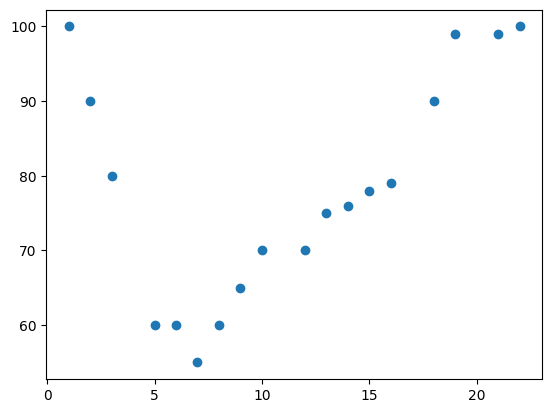

In [47]:
plt.scatter(x,y)
plt.show()

In [48]:
X=np.array(x).reshape(-1,1)
X

array([[ 1],
       [ 2],
       [ 3],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10],
       [12],
       [13],
       [14],
       [15],
       [16],
       [18],
       [19],
       [21],
       [22]])

In [49]:
Y=np.array(y).reshape(-1,1)
Y

array([[100],
       [ 90],
       [ 80],
       [ 60],
       [ 60],
       [ 55],
       [ 60],
       [ 65],
       [ 70],
       [ 70],
       [ 75],
       [ 76],
       [ 78],
       [ 79],
       [ 90],
       [ 99],
       [ 99],
       [100]])

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [52]:
from sklearn.preprocessing import PolynomialFeatures

In [53]:
p2=PolynomialFeatures(degree=2)
p2

PolynomialFeatures()

In [54]:
X_p2=p2.fit_transform(X)
X_p2

array([[  1.,   1.,   1.],
       [  1.,   2.,   4.],
       [  1.,   3.,   9.],
       [  1.,   5.,  25.],
       [  1.,   6.,  36.],
       [  1.,   7.,  49.],
       [  1.,   8.,  64.],
       [  1.,   9.,  81.],
       [  1.,  10., 100.],
       [  1.,  12., 144.],
       [  1.,  13., 169.],
       [  1.,  14., 196.],
       [  1.,  15., 225.],
       [  1.,  16., 256.],
       [  1.,  18., 324.],
       [  1.,  19., 361.],
       [  1.,  21., 441.],
       [  1.,  22., 484.]])

In [55]:
X_train_p2=p2.fit_transform(X_train)
X_test_p2=p2.fit_transform(X_test)
X_test_p2

array([[  1.,   1.,   1.],
       [  1.,   2.,   4.],
       [  1.,  10., 100.],
       [  1.,   7.,  49.]])

In [91]:
from sklearn.linear_model import LinearRegression
lr2=LinearRegression()
lr

LinearRegression()

In [92]:
lr2.fit(X_train_p2,Y_train)

LinearRegression()

In [93]:
lr2.coef_

array([[ 0.        , -2.63765375,  0.18449289]])

In [94]:
lr2.intercept_

array([74.93341705])

In [95]:
Y_pred=lr2.predict(X_test_p2)
Y_pred

array([[72.48025619],
       [70.39608111],
       [67.00616871],
       [65.50999248]])

In [61]:
from sklearn.metrics import mean_squared_error,r2_score

In [62]:
mean_squared_error(Y_test,Y_pred)

315.26822577370103

In [63]:
r2_score(Y_test,Y_pred)

-0.034726484590608564

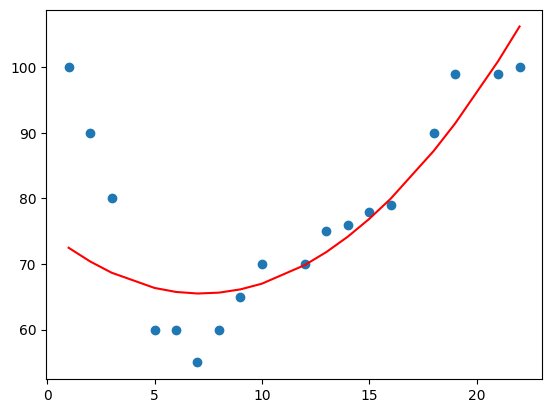

In [96]:
plt.scatter(X,Y)
plt.plot(X,lr2.predict(X_p2),color='red')
plt.show()

In [97]:
p3 = PolynomialFeatures(degree=3)

X_train_p3 = p3.fit_transform(X_train)
X_test_p3 = p3.transform(X_test)

lr3 = LinearRegression()
lr3.fit(X_train_p3, Y_train)

LinearRegression()

In [98]:
Y_pred_p3=lr3.predict(X_test_p3)
Y_pred_p3

array([[95.12935604],
       [84.73881985],
       [62.63857883],
       [60.58438659]])

In [87]:
mean_squared_error(Y_test,Y_pred_p3)

34.194771139014065

In [88]:
r2_score(Y_test,Y_pred_p3)

0.8877710075437487

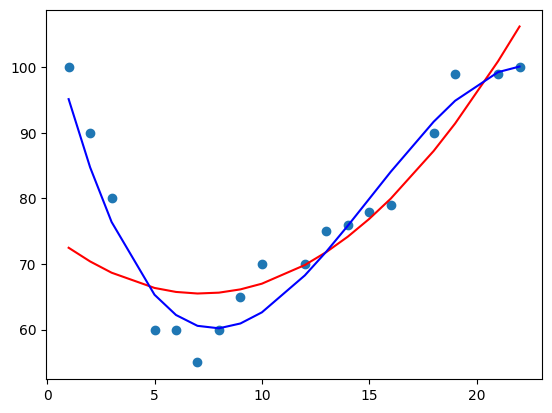

In [99]:
plt.scatter(X, Y),
plt.plot(X, lr2.predict(X_p2), color='red'),
plt.plot(X, lr3.predict(X_p3), color='blue')
plt.show()

In [102]:
mse=[]
rsq=[]
for n in range(1,11):
  pn=PolynomialFeatures(degree=n)
  X_Pn=pn.fit_transform(X)
  X_train_pn=pn.fit_transform(X_train)
  X_test_pn=pn.fit_transform(X_test)
  lrn=LinearRegression()
  lrn.fit(X_train_pn,Y_train)
  Y_predn=lrn.predict(X_test_pn)
  mse.append(mean_squared_error(Y_test,Y_predn))
  rsq.append(r2_score(Y_test,Y_predn))

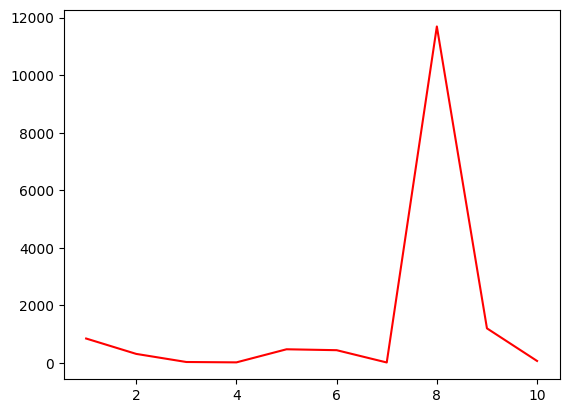

In [105]:
plt.plot(range(1,11),mse, color='red')
plt.show()

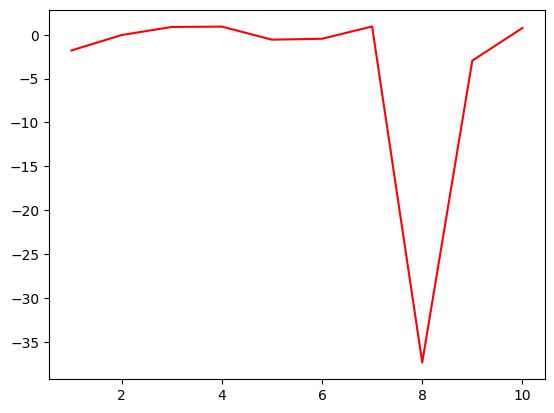

In [106]:
plt.plot(range(1,11),rsq, color='red')
plt.show()

In [110]:
mse=[]
rsq=[]
for n in range(1,8):
  pn=PolynomialFeatures(degree=n)
  X_Pn=pn.fit_transform(X)
  X_train_pn=pn.fit_transform(X_train)
  X_test_pn=pn.fit_transform(X_test)
  lrn=LinearRegression()
  lrn.fit(X_train_pn,Y_train)
  Y_predn=lrn.predict(X_test_pn)
  mse.append(mean_squared_error(Y_test,Y_predn))
  rsq.append(r2_score(Y_test,Y_predn))

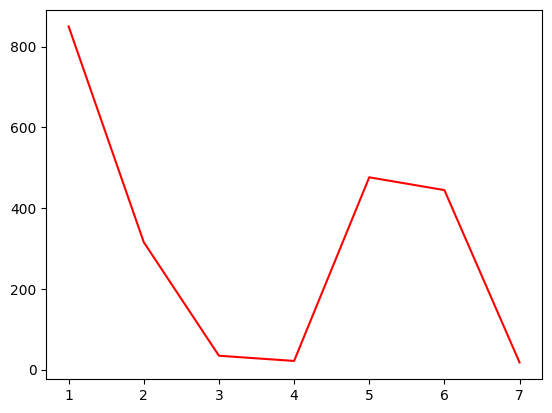

In [111]:
plt.plot(range(1,8),mse,color='red')
plt.show()

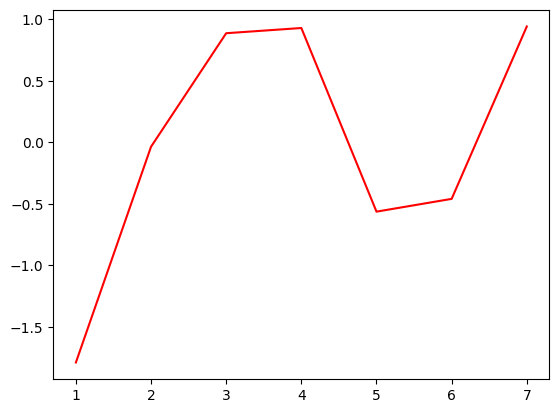

In [112]:
plt.plot(range(1,8),rsq,color='red')
plt.show()

In [113]:
import pandas as pd

In [114]:
cars=pd.read_csv('https://raw.githubusercontent.com/juliandnl/redi_ss20/master/cars.csv')
cars.head()

,Make,Model,Year,Variant,Kms,Price,Doors,Kind,Location
0,Volkswagen,Vento,2012,2.5 Luxury 170cv,99950,360000,4.0,Sedán,Córdoba
1,Ford,Ranger,2012,2.3 Cd Xl Plus 4x2,140000,320000,2.0,Pick-Up,Entre Ríos
2,Volkswagen,Fox,2011,1.6 Trendline,132000,209980,5.0,Hatchback,Bs.as. G.b.a. Sur
3,Ford,Ranger,2017,3.2 Cd Xls Tdci 200cv Automática,13000,798000,4.0,Pick-Up,Neuquén
4,Volkswagen,Gol,2013,1.4 Power 83cv 3 p,107000,146000,3.0,Hatchback,Córdoba


In [115]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Make      10000 non-null  object 
 1   Model     10000 non-null  object 
 2   Year      10000 non-null  int64  
 3   Variant   10000 non-null  object 
 4   Kms       10000 non-null  int64  
 5   Price     10000 non-null  int64  
 6   Doors     10000 non-null  float64
 7   Kind      10000 non-null  object 
 8   Location  10000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 703.3+ KB


In [146]:
X_cars=cars[['Year','Kms']]
X

,Year,Kms
0,2012,99950
1,2012,140000
2,2011,132000
3,2017,13000
4,2013,107000
...,...,...
9995,2016,67000
9996,2012,120000
9997,2012,89000
9998,2013,76000


In [147]:
Y_cars=cars['Price']
Y

,Price
0,360000
1,320000
2,209980
3,798000
4,146000
...,...
9995,399000
9996,240000
9997,250000
9998,295000


In [149]:
print(len(X_cars))

10000


In [150]:
Y_cars=np.array(Y_cars).reshape(-1,1)
print(len(Y_cars))

10000


In [151]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X_cars,Y_cars,test_size=0.2,random_state=42)
from sklearn.preprocessing import PolynomialFeatures

In [152]:
cars_p2=PolynomialFeatures(degree=2)
cars_p2

PolynomialFeatures()

In [160]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

mse = []
rsq = []

pn = PolynomialFeatures(degree=2)

x_train_cars_p2 = pn.fit_transform(x_train)

x_test_cars_p2 = pn.transform(x_test)

lr_cars_p2 = LinearRegression()
lr_cars_p2.fit(x_train_cars_p2, y_train)

y_pred_cars_p2 = lr_cars_p2.predict(x_test_cars_p2)

mse.append(mean_squared_error(y_test, y_pred_cars_p2))
rsq.append(r2_score(y_test, y_pred_cars_p2))


In [162]:
rsq

[0.2384625124369273]

In [161]:
mse

[22004375704.625423]

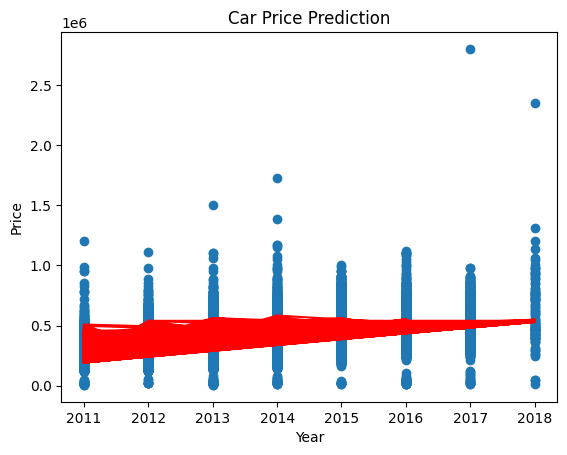

In [158]:
plt.scatter(X_cars['Year'], Y_cars)
plt.plot(X_cars['Year'], lr_cars_p2.predict(pn.transform(X_cars)), color='red')
plt.title('Car Price Prediction')
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()